In [7]:
import numpy as np

from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.quantum_info import SparsePauliOp
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import EstimatorV2 as Estimator

import matplotlib.pyplot as plt
import matplotlib.ticker as tck

This notebook is a pedagogical exploration of the Bell inequality through the CHSH inequality. We create an entengled pair and measure each qbit on two different bases. The bases for the first qubit are A and a, while for the second qubit B and b.

The CHSH inequality is $S_1 = A(B-b) + a (B+b)$.

Because A, a, b, and B are dichotomic, $S_1$ has eigenvalues of $ \pm 2$ and $|\langle S_1\rangle| \leq 2$

Also define $S_2 = A(B+b)- a(B-b)$, $|\langle S_1\rangle| \leq 2$.

Classically, these inequalities must hold, but quantum mechanically they can be violated. 

In this notebook, we create Bell states, use the Estimator to evaluate expectations, and plot our findings.



Find the backend with the fewest number of jobs

The code below only has to be initiated once per project. This couples the Jupyter notebook with my IBM account. 

In [16]:
from qiskit_ibm_runtime import QiskitRuntimeService

QiskitRuntimeService.save_account(
token="YCGBzKxGTNtgIVwdG7HlACqye1DcvT0J4keIm-16o0LM", # Use the 44-character API_KEY you created and saved from the IBM Quantum Platform Home dashboard
instance="crn:v1:bluemix:public:quantum-computing:us-east:a/0a9197f955424bd8b14955b7bdf7464b:2c239d66-06ff-44b7-bf98-26730e324a42::", # Optional
)

In [19]:
service = QiskitRuntimeService()
backend = service.least_busy(operational = True, simulator = False, min_num_qubits = 127)
backend.name

'ibm_fez'

Create the circuit

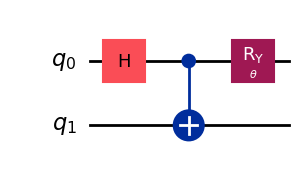

In [11]:
theta = Parameter("$\\theta$")
chsh_circuit= QuantumCircuit(2)
chsh_circuit.h(0)
chsh_circuit.cx(0,1)
chsh_circuit.ry(theta,0)
chsh_circuit.draw(output="mpl",  idle_wires= False, style ="iqp")

Create a list of phase values with which A,a will be rotated w.r.t B,b

In [12]:
num_phases = 21
phases = np.linspace(0,2 * np.pi , num_phases)
#Phases should be expressed as a list of lists in order to work
individual_phases = [[ph] for ph in phases]

Introduce the observables ZZ, ZX, XZ, XX

In [13]:
#<AB> -<Ab> + <aB> + <ab> -> <ZZ> - <ZX> + <XZ> + <XX>
observable1 = SparsePauliOp.from_list(
    [("ZZ",1), ("ZX",-1),("XZ",1), ("XX",1)]
)

#<AB> + <Ab> - <aB> + <ab> -> <ZZ> + <ZX> - <XZ> + <XX>
observable2 = SparsePauliOp.from_list(
    [("ZZ",1), ("ZX",1),("XZ",-1), ("XX",1)]
)



To reduce total job execution time, V2 primitives only accept circuits and observables that conforms to the instructions and connectivity supported by the target system. 

ISA circuit:

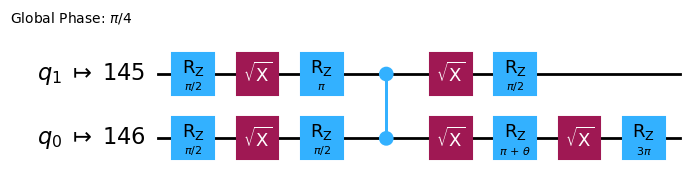

In [20]:
target = backend.target
pm = generate_preset_pass_manager(target = target, optimization_level = 3)

chsh_isa_circuit = pm.run(chsh_circuit)
chsh_isa_circuit.draw(output="mpl" , idle_wires=False, style = "iqp")

Similarly, we need to transform the observables to make it backend compatible before running jobs. We can perform the ttransformation using the apply_layout 

In [21]:
isa_observable1 = observable1.apply_layout(layout=chsh_isa_circuit.layout)
isa_observable2 = observable2.apply_layout(layout=chsh_isa_circuit.layout)


Create a qiskit runtime estimator primitive to compute our expectation values.
EstimatorV2.run() takes an iterable of primitive unified blocs (PUBs). Each PUB is an iterable in the format (circuit, observables, parameter_values: Optional, precision: Optional)

In [22]:
estimator = Estimator(mode = backend)

pub = (chsh_isa_circuit, #ISA circuit
       [[isa_observable1],[isa_observable2]], #Observables
        individual_phases, #parameters    
       )

job_result = estimator.run(pubs = [pub]).result()

The estimator returns expectation values for $S_1$ and $S_2$

In [ ]:
#vals
chsh1_est = job_result[0].data.evs[0]
chsh2_est = job_result[0].data.evs[1]

#std errs
errors1 = job_result[0].data.stds[0]
errors2 = job_result[0].data.stds[1]


Now we can plot the results

<function matplotlib.pyplot.show(close=None, block=None)>

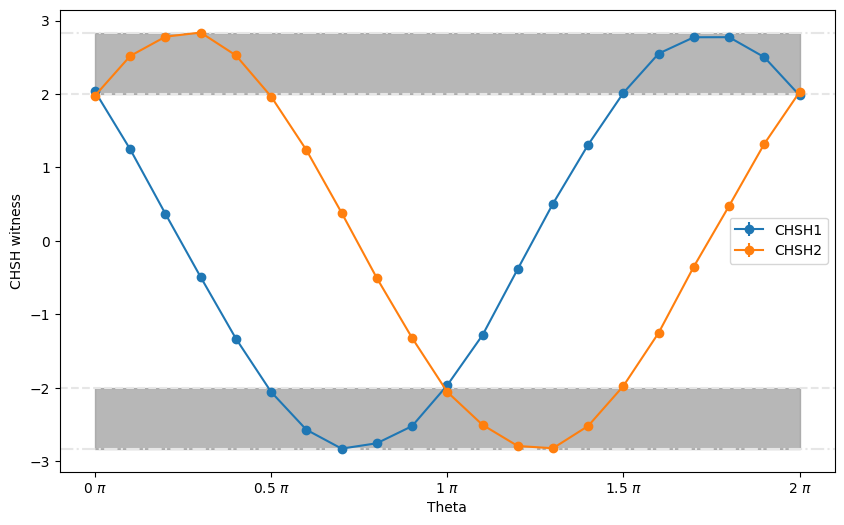

In [36]:
fig, ax = plt.subplots(figsize = (10,6))

#results from hardware
ax.errorbar(phases / np.pi , chsh1_est, yerr = errors1,fmt = "o-", label = "CHSH1", zorder = 3)
ax.errorbar(phases / np.pi , chsh2_est, yerr = errors2, fmt ="o-", label = "CHSH2", zorder = 3)

#classical bound
ax.axhline( y=2, color="0.9", linestyle = "--")
ax.axhline( y=-2, color="0.9", linestyle = "--")

#quantum bound
ax.axhline( y=np.sqrt(2) *2, color="0.9", linestyle = "-.")
ax.axhline( y=- np.sqrt(2) *2, color="0.9", linestyle = "-.")
ax.fill_between(phases/ np.pi, 2,2 * np.sqrt(2) , color = "0.6", alpha = 0.7)
ax.fill_between(phases/ np.pi, -2,-2 * np.sqrt(2) , color = "0.6", alpha = 0.7)

#set x tick, label and legend
ax.xaxis.set_major_formatter(tck.FormatStrFormatter("%g $\\pi$"))
ax.xaxis.set_major_locator(tck.MultipleLocator(base = 0.5))
plt.xlabel("Theta")
plt.ylabel("CHSH witness")
plt.legend()
plt.show

